# ЛР №1
# Боев Савелий Сергеевич

## Все нужные либы + фиксирование сида

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import random
import os

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"{device}")

cuda


## Посмотрим на данные

In [3]:
df = pd.read_csv("/content/cybersequrity.csv")

feature_cols = df.drop("Class", axis=1).columns

X = df.drop('Class', axis=1).values
y = df['Class'].values


X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print(f"Train {X_train.shape} Val {X_val.shape} Test {X_test.shape}")

Train (6000, 15) Val (2000, 15) Test (2000, 15)


In [4]:
train_before = pd.DataFrame(X_train, columns=feature_cols)
train_before["Class"] = y_train
print(train_before.head(10))

   svcscan.fs_drivers  callbacks.ngeneric  \
0                26.0                 8.0   
1                26.0                 8.0   
2                26.0                 8.0   
3                26.0                 8.0   
4                26.0                 8.0   
5                26.0                 8.0   
6                26.0                 8.0   
7                26.0                 8.0   
8                26.0                 8.0   
9                26.0                 8.0   

   psxview.not_in_eprocess_pool_false_avg  psxview.not_in_eprocess_pool  \
0                                     0.0                           0.0   
1                                     0.0                           0.0   
2                                     0.0                           0.0   
3                                     0.0                           0.0   
4                                     0.0                           0.0   
5                                     0.0             

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [6]:
train_after = pd.DataFrame(X_train, columns=feature_cols)
train_after["Class"] = y_train
print(train_after.head(10))

   svcscan.fs_drivers  callbacks.ngeneric  \
0            0.018935             0.01826   
1            0.018935             0.01826   
2            0.018935             0.01826   
3            0.018935             0.01826   
4            0.018935             0.01826   
5            0.018935             0.01826   
6            0.018935             0.01826   
7            0.018935             0.01826   
8            0.018935             0.01826   
9            0.018935             0.01826   

   psxview.not_in_eprocess_pool_false_avg  psxview.not_in_eprocess_pool  \
0                               -0.060824                     -0.044766   
1                               -0.060824                     -0.044766   
2                               -0.060824                     -0.044766   
3                               -0.060824                     -0.044766   
4                               -0.060824                     -0.044766   
5                               -0.060824             

In [7]:
print("Train кол-во классов", np.bincount(y_train))
print("Val   кол-во классов", np.bincount(y_val))
print("Test  кол-во классов", np.bincount(y_test))

Train кол-во классов [2942 3058]
Val   кол-во классов [ 981 1019]
Test  кол-во классов [ 981 1019]


Хорошее разделение классов

## Загрузчик данных

In [8]:
class MyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = MyDataset(X_train, y_train)
val_dataset = MyDataset(X_val, y_val)
test_dataset = MyDataset(X_test, y_test)

BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Согласно ТЗ разбил на 60/20/20. В качестве размера батча взял 128, просто на глаз. При обучении моделей возможно поменяю

## Baseline model

In [9]:
class BaselineMLP(nn.Module):
    def __init__(self, input_dim):
        super(BaselineMLP, self).__init__()
        self.layer1 = nn.Linear(input_dim, 128)
        self.act1 = nn.ReLU()

        self.layer2 = nn.Linear(128, 64)
        self.act2 = nn.ReLU()

        self.output = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.act1(self.layer1(x))
        x = self.act2(self.layer2(x))
        x = self.sigmoid(self.output(x))
        return x

input_dim = X_train.shape[1]
model = BaselineMLP(input_dim).to(device)
print(model)

BaselineMLP(
  (layer1): Linear(in_features=15, out_features=128, bias=True)
  (act1): ReLU()
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (act2): ReLU()
  (output): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


В качестве бейзлайна взял многослоный перцептрон. Первый слой расширяю до 128 для того, чтобы поймать больше зависимостей у признаков. Потом понижаю до 64, чтобы убрать шум и выделить наиболее важные признаки. Ну и так как у нас задача бин классификации мы на последнем слое все наши 64 признака сужаем в 1, чтобы получить числовое описание этих признаков в одном числе. Через Sigmoid превращаем в вероятностное значение, чтобы понять это 0 или 1.

В качестве ф-кии активации взял ReLU, так как он достаточно быстрый и не дает градиентам затухать.

## Цикл обучения

In [10]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)

def eval_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds = []
    targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item() * X_batch.size(0)

            preds.extend((outputs > 0.5).float().cpu().numpy())
            targets.extend(y_batch.cpu().numpy())

    return running_loss / len(loader.dataset), targets, preds

Тут ничего особенного, просто циклы для валидации и обучения

Порог в валидации 0.5. Если выше, то 1. Если ниже, то 0

## Baseline train

Эпоха 5/50 | Train loss: 0.5862 | Val loss: 0.5602
Эпоха 10/50 | Train loss: 0.5056 | Val loss: 0.4809
Эпоха 15/50 | Train loss: 0.4743 | Val loss: 0.4582
Эпоха 20/50 | Train loss: 0.4654 | Val loss: 0.4483
Эпоха 25/50 | Train loss: 0.4624 | Val loss: 0.4403
Эпоха 30/50 | Train loss: 0.4536 | Val loss: 0.4356
Эпоха 35/50 | Train loss: 0.4440 | Val loss: 0.4360
Эпоха 40/50 | Train loss: 0.4347 | Val loss: 0.4276
Эпоха 45/50 | Train loss: 0.4295 | Val loss: 0.4299
Эпоха 50/50 | Train loss: 0.4270 | Val loss: 0.4272


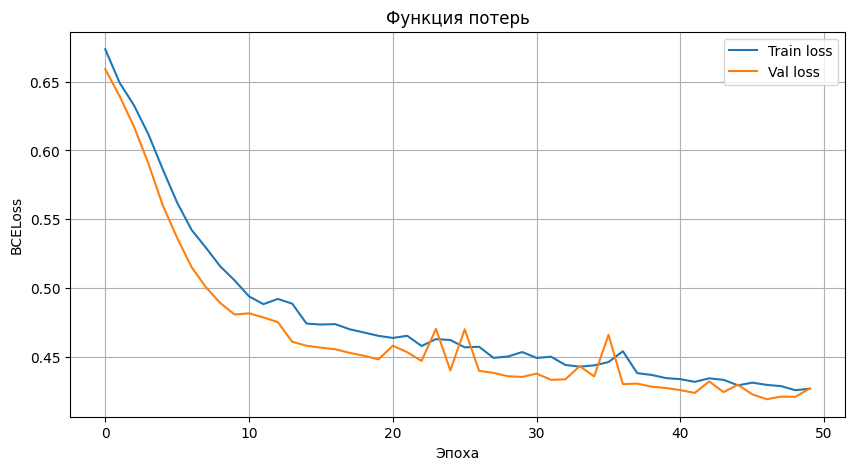

              precision    recall  f1-score   support

         0.0       0.82      0.71      0.76       981
         1.0       0.75      0.85      0.80      1019

    accuracy                           0.78      2000
   macro avg       0.79      0.78      0.78      2000
weighted avg       0.79      0.78      0.78      2000



In [11]:
EPOCHS = 50
LEARNING_RATE = 1e-3

criterion = nn.BCELoss()

WEIGHT_DECAY = 1e-2
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, _, _ = eval_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Эпоха {epoch+1}/{EPOCHS} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.title('Функция потерь')
plt.xlabel('Эпоха')
plt.ylabel('BCELoss')
plt.legend()
plt.grid(True)
plt.show()

_, y_true, y_pred = eval_epoch(model, test_loader, criterion, device)
print(classification_report(y_true, y_pred))

В качестве оптимизатора выбрал AdamW. Он лучше штрафует за большие веса, чтобы не было сразу переобучения, чем Adam

Функция потерь - BCELoss (по ТЗ)

50 эпох с lr 1e-3

По графикам loss плавно идет вниз (почти) на трейне и валидации. Переобучения нет.

По метрика на тесте Accuracy 0.78. Модель очень хорошо находит почти все вирусы, но при этом часто ошибается, помечая чистые файлы как вредоносные.

Получился хороший baseline

## Upgraded baseline w/o batchnorm

In [12]:
class DropoutMLP(nn.Module):
    def __init__(self, input_dim):
        super(DropoutMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(p=0.2),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.2),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

final_model = DropoutMLP(input_dim).to(device)
print(final_model)

DropoutMLP(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


Сначала решил посмотреть как выглядит улучшенная версия только с Dropout

Добавил его после каждой активации, чтобы модель не заучивала данные наизусть, а искала общие закономерности

Из-за того что dropout отключает часть нейронов, то расширил слои в 2 раза

p взял 0.2, подумал что оптимально для табличных данных, чтобы не сильно шуметь и не терять пртзнаки

Эпоха 10/60 | Train loss: 0.5068 | Val loss: 0.4732
Эпоха 20/60 | Train loss: 0.4505 | Val loss: 0.4235
Эпоха 30/60 | Train loss: 0.4197 | Val loss: 0.4092
Эпоха 40/60 | Train loss: 0.4046 | Val loss: 0.3929
Эпоха 50/60 | Train loss: 0.3870 | Val loss: 0.3706
Эпоха 60/60 | Train loss: 0.3794 | Val loss: 0.3711


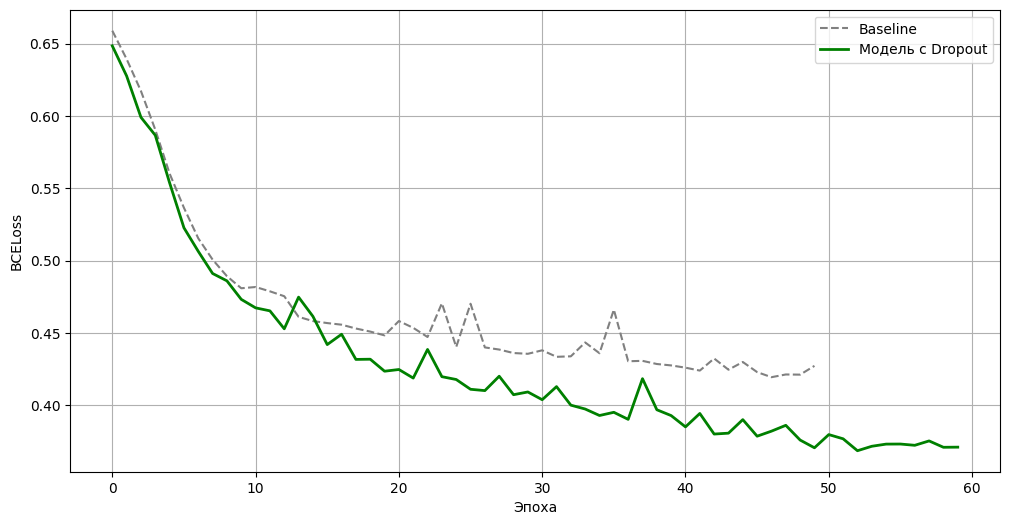

              precision    recall  f1-score   support

         0.0       0.81      0.82      0.82       981
         1.0       0.83      0.81      0.82      1019

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000



In [13]:
optimizer_final = optim.AdamW(final_model.parameters(), lr=0.001, weight_decay=1e-4)

final_train_losses = []
final_val_losses = []
EPOCHS = 60

for epoch in range(EPOCHS):
    train_loss = train_epoch(final_model, train_loader, criterion, optimizer_final, device)
    val_loss, _, _ = eval_epoch(final_model, val_loader, criterion, device)

    final_train_losses.append(train_loss)
    final_val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Эпоха {epoch+1}/{EPOCHS} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")

plt.figure(figsize=(12, 6))

if "val_losses" in globals():
    limit = min(len(val_losses), len(final_val_losses))
    plt.plot(val_losses[:limit], label="Baseline", linestyle="--", color="gray")

plt.plot(final_val_losses, label="Модель с Dropout", linewidth=2, color="green")
plt.xlabel("Эпоха")
plt.ylabel("BCELoss")
plt.legend()
plt.grid(True)
plt.show()

_, y_true_final, y_pred_final = eval_epoch(final_model, test_loader, criterion, device)
print(classification_report(y_true_final, y_pred_final))

Оставил AdamW, но weight_decay уменьшил до 1e-4. Так как у нас теперь есть Dropout, то сильная L2-регуляризация не нужна

Количество эпох увеличил до 60, так как из-за dropout может потребуется больше времени чтобы сойтись

С самого начала модель с dropout начала лучше чем бейзлайн и эта тендация сохранилась до конца.

Финальный Loss упал до 0.38, когда у бейзлайна было около 0.42. Внесенные улучшения действительно помогли

Accuracy 0.82 стала лучше

## Upgraded baseline with BatchNorm

In [14]:
class BatchNormMLP(nn.Module):
    def __init__(self, input_dim):
        super(BatchNormMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.2),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

final_model = BatchNormMLP(input_dim).to(device)
print(final_model)

BatchNormMLP(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


Решил объединить Dropout и BatchNorm

Слои теперь вот так идут Linear -> BatchNorm -> ReLU -> Dropout

Сначала нормализуются данные, а уже потом их принимает ReLU. Должно быть стабильнее и быстрее обучение

Ширина слоев такая же

И напоминаю что batch 128, что должно быть оптимально для BatchNorm

Эпоха 10/60 | Train loss: 0.4943 | Val loss: 0.5409
Эпоха 20/60 | Train loss: 0.4623 | Val loss: 0.4905
Эпоха 30/60 | Train loss: 0.4372 | Val loss: 0.4551
Эпоха 40/60 | Train loss: 0.4250 | Val loss: 0.4684
Эпоха 50/60 | Train loss: 0.4239 | Val loss: 0.4414
Эпоха 60/60 | Train loss: 0.4068 | Val loss: 0.4248


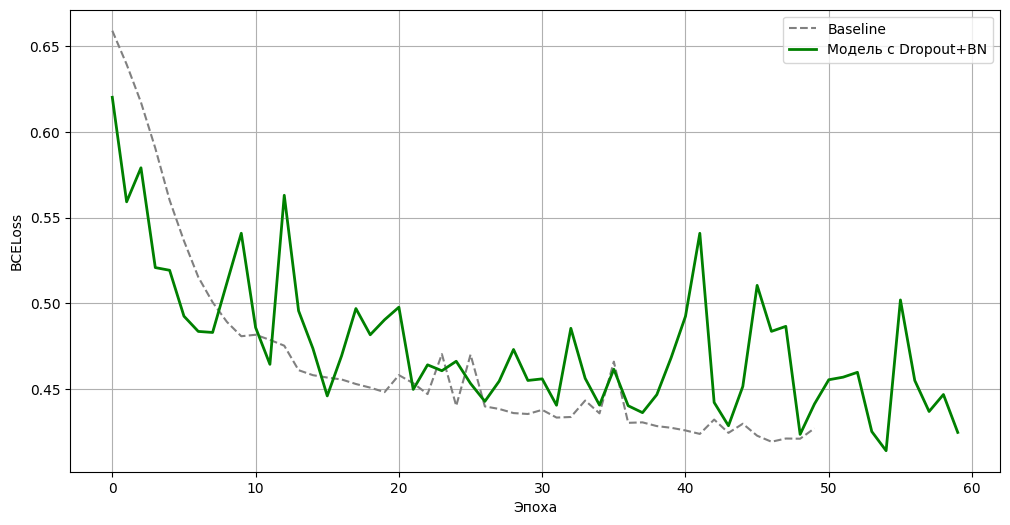

              precision    recall  f1-score   support

         0.0       0.80      0.77      0.79       981
         1.0       0.79      0.82      0.80      1019

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000



In [15]:
optimizer_final = optim.AdamW(final_model.parameters(), lr=0.001, weight_decay=1e-4)

final_train_losses = []
final_val_losses = []
EPOCHS = 60

for epoch in range(EPOCHS):
    train_loss = train_epoch(final_model, train_loader, criterion, optimizer_final, device)
    val_loss, _, _ = eval_epoch(final_model, val_loader, criterion, device)

    final_train_losses.append(train_loss)
    final_val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Эпоха {epoch+1}/{EPOCHS} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")

plt.figure(figsize=(12, 6))

if "val_losses" in globals():
    limit = min(len(val_losses), len(final_val_losses))
    plt.plot(val_losses[:limit], label="Baseline", linestyle="--", color="gray")

plt.plot(final_val_losses, label="Модель с Dropout+BN", linewidth=2, color="green")
plt.xlabel("Эпоха")
plt.ylabel("BCELoss")
plt.legend()
plt.grid(True)
plt.show()

_, y_true_final, y_pred_final = eval_epoch(final_model, test_loader, criterion, device)
print(classification_report(y_true_final, y_pred_final))

Гиперпараметры не изменились, все тоже самое

Результаты хуже, loss выше бейзлайна и метрики тоже. Accuracy тоже такой же

Наверное для такого датасета стала многовато использование регуляризации. У нас и BatchNorm и Dropout и из за этого модели тяжело

Просто использование Dropout дало наилучший результат
